In [36]:
from xaikd import datasets, attributors, models
from xaikd.utils import metrics
from matplotlib import pyplot as plt 

import numpy as np 

import torch

from torch.nn import functional as F

from tqdm import tqdm 

In [44]:
LAYER = "layer3"

MODEL_NAME = "cifar100-resnet18-p1"

In [4]:
dataset = datasets.construct("cifar100")

In [45]:
model = models.get_model(MODEL_NAME)

In [8]:
act = attributors.extract_activation(
    model, 
    layer=LAYER,
    dataset=dataset, 
    data_loader=dataset.loader(train_split=True)
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 782/782 [08:52<00:00,  1.47it/s]


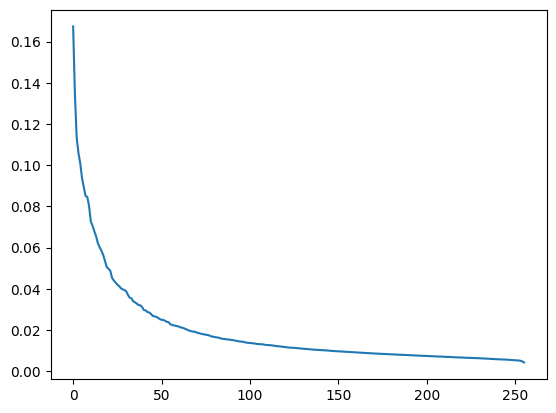

In [13]:
act_mean = np.mean(act, axis=0)
cov = np.cov(act.T)
eigvals, eigvecs = np.linalg.eigh(cov)

sorted_indices = np.argsort(-eigvals)
eigvals = eigvals[sorted_indices]
eigvecs = eigvecs[:, sorted_indices]
plt.plot(eigvals)

In [14]:
val_dl = dataset.loader(train_split=False)

In [20]:
def construct_fh_hook_projection(U, mean):

    A = torch.from_numpy(U @ U.T).float().unsqueeze(2).unsqueeze(3)
    mean = torch.from_numpy(mean).reshape((1, -1, 1, 1))
    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        return F.conv2d(output - mean, A) + mean

    return fh

In [26]:
def compute_acc(model, k):
    
    module = getattr(model, LAYER)[-1]
    U = eigvecs[:, :k]
    
    try:
        hook = module.register_forward_hook(construct_fh_hook_projection(U, act_mean))

        acc = metrics.accuracy(model, val_dl, num_classes=100, device="cpu")
        print(f"acc@{k}={acc:.4f}")
    finally:
        hook.remove()
        
compute_acc(model, k=100)

acc@100=0.6606


In [51]:
class ProjectionLayer(torch.nn.Module):
    def __init__(self, U, mean):
        
        super().__init__()
        
        self.A = torch.from_numpy(U @ U.T).float().unsqueeze(2).unsqueeze(3)
        self.mean = torch.from_numpy(mean).reshape((1, -1, 1, 1))

    def forward(self, x):
        return F.conv2d(x - self.mean, self.A) + self.mean

In [87]:
modified_model = models.get_model(MODEL_NAME)
setattr(modified_model, LAYER, 
    torch.nn.Sequential(
        getattr(modified_model, LAYER),
        ProjectionLayer(eigvecs[:, :20], act_mean)
    )
)


modified_model(torch.randn(10, 3, 32, 32))

tensor([[ 3.8979e-01,  1.0448e-01, -7.2464e-01, -8.6894e-03,  2.7811e+00,
          3.1698e-01, -1.2892e+00,  5.9689e-01,  3.9094e+00,  1.2338e-01,
          1.1895e+00, -2.5098e+00,  6.3966e+00,  2.7264e-01,  9.8482e-01,
         -5.5450e-01,  3.1626e+00, -1.3992e-01,  3.9515e-01, -8.6702e-01,
         -1.8017e+00,  1.1818e+00,  2.6965e-01, -2.3773e+00, -5.9228e-01,
          8.5900e-01, -1.5752e-01,  2.6124e+00,  4.1961e-01,  8.5083e-01,
         -2.5733e+00, -3.6463e-01,  6.8343e-01,  5.6718e+00, -2.9444e+00,
         -3.3185e+00, -1.8251e+00, -2.9673e-01, -3.0282e+00, -8.8162e-01,
          1.0433e+00,  2.1238e+00, -8.0235e-01, -2.3158e+00, -2.5540e+00,
          3.2480e+00,  2.4832e+00, -5.8868e-01,  3.5853e-01,  1.7478e+00,
         -3.9526e-01, -2.8543e+00, -1.7548e+00,  1.3467e+00, -1.4446e+00,
          1.9189e+00, -4.4630e-01,  3.9049e+00, -2.4191e+00,  5.8762e-01,
          1.0086e+00, -2.3947e-01,  1.4628e-01, -4.2679e-01, -2.1381e+00,
         -2.9346e-01, -2.2367e+00, -2.

In [90]:
metrics.accuracy(modified_model, val_dl, num_classes=100, device="cpu")

0.3167000114917755

In [55]:
metrics.accuracy(model, val_dl, num_classes=100, device="cpu")

0.6840000152587891

In [77]:
def compute_grad_norm(model, threshold=1000):
    
    count = 0
    
    arr_norms = []
    for x, y in tqdm(val_dl):
        
        x.requires_grad_(True)
        
        model(x)[:, y].sum().backward()
                
        grad = x.grad.flatten(start_dim=1)
        arr_norms.append(
            torch.linalg.norm(grad, dim=1).numpy()
        )
        
        count += grad.shape[0]
        
        if count > 2000:
            break
    
    return np.concatenate(arr_norms)
    

normal_model_grad = compute_grad_norm(model)

normal_model_grad.shape

 20%|█████████████████████████████████████████████████▎                                                                                                                                                                                                        | 31/157 [00:36<02:30,  1.19s/it]


(2048,)

In [88]:
modified_model_grad = compute_grad_norm(modified_model)

 20%|█████████████████████████████████████████████████▎                                                                                                                                                                                                        | 31/157 [00:37<02:34,  1.22s/it]


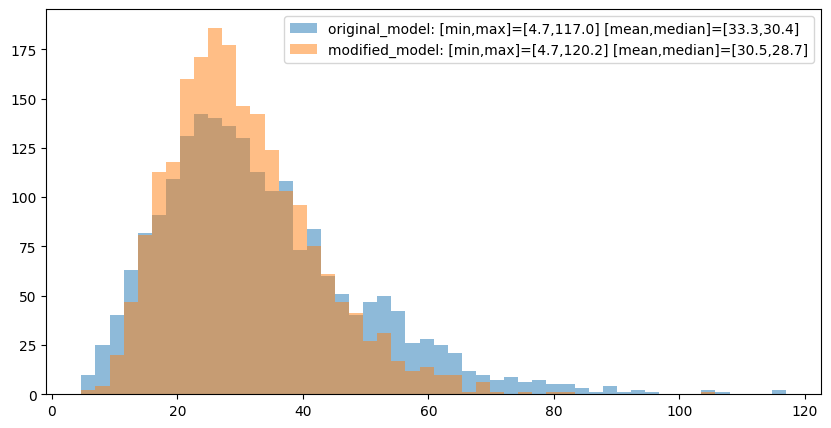

In [91]:
def viz():
    
    
    plt.figure(figsize=(10, 5))
    bins = None
    for label, grad in [
        ("original_model", normal_model_grad),
        ("modified_model", modified_model_grad)  
    ]:
        
        label = f"{label}: [min,max]=[{np.min(grad):.1f},{np.max(grad):.1f}] [mean,median]=[{np.mean(grad):.1f},{np.median(grad):.1f}]"
        _, bins, _ = plt.hist(
            grad, label=label, bins=bins if bins is not None else 50,
            alpha=0.5
        )
    plt.legend()
viz()


In [63]:
normal_model_grad.shape

(4, 64)